<a href="https://colab.research.google.com/github/Fatimalbasha/KAUST-Labs2026/blob/main/Stage3/Day_2/Day2_1_Exercise.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

![image.png](https://i.imgur.com/a3uAqnb.png)

# **📌 Working with Different Dataset Structures**
---

## **Purpose of This Lab**

In real-world projects, datasets don't always come in the same format:
- Some are **pre-split** into train/validation/test folders
- Others are **unsplit**, requiring you to create splits manually
- Some include **CSV files** with labels, while others use **folder-based labels**
- Segmentation datasets have **paired images and masks** instead of class labels
- Plotting some

**This lab trains you to:**
1. **Inspect and understand** different dataset structures
2. **Build custom Dataset classes** for various data formats
3. **Handle both classification and segmentation** datasets
4. **Debug and visualize** data before training

By the end of this lab, you will be confident working with any dataset structure you encounter.

---

## **What We Will Cover**

### **Part 1: Image Classification Datasets**
- Pre-split datasets (train/val/test folders already separated)
- Unsplit datasets (all images in one folder, requiring manual splitting)
- CSV-based datasets (labels stored in a CSV file)


✅ Debugging dataset loading issues

In [ ]:
# Uncomment these lines if running on Google Colab
import os
os.environ["KAGGLEHUB_CACHE"] = "/content/data"

---

# **Part 1: Image Classification Datasets**

In this section, we'll work with **three types** of classification dataset structures:

1. **Pre-split dataset** - Already divided into train/validation/test folders
2. **Unsplit dataset** - All images in one folder, needs manual splitting
3. **CSV-labeled dataset** - Labels stored in a CSV file instead of folder names

We'll build a **complete example** for the first type, then leave the others as exercises.

## **Example 1: Pre-Split Dataset (Train/Val/Test)**

**Dataset:** Fruit and Vegetable Image Recognition  
**Structure:** Images are already organized into `train/`, `validation/`, and `test/` folders

This is the **easiest** type to work with because the data is already split for us.

In [ ]:
# Import required libraries
import os
import kagglehub
import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image
import matplotlib.pyplot as plt

## Fruits and Vegetables Image Recognition Dataset

![image.png](https://storage.googleapis.com/kaggle-datasets-images/952827/1613819/d6088a240b65b74c5b8fa735958b08c5/dataset-cover.jpg?t=2020-11-03-05-53-42)

In [ ]:
# Download the dataset from Kaggle
path = kagglehub.dataset_download("kritikseth/fruit-and-vegetable-image-recognition")
print("Dataset downloaded to:", path)

Using Colab cache for faster access to the 'fruit-and-vegetable-image-recognition' dataset.
Dataset downloaded to: /kaggle/input/fruit-and-vegetable-image-recognition


### **Step 1: Inspect the Dataset Structure**

Before writing any code, **always** inspect the dataset structure first.  
This helps you understand:
- How folders are organized
- Where images are located
- How labels are defined (folder names, CSV, etc.)


Classes in train folder (first 10):
  0: apple - 68 images
  1: banana - 75 images
  2: beetroot - 88 images
  3: bell pepper - 90 images
  4: cabbage - 92 images
  5: capsicum - 89 images
  6: carrot - 82 images
  7: cauliflower - 79 images
  8: chilli pepper - 87 images
  9: corn - 87 images

Total classes: 36


**What we discovered:**
- ✅ Folders: `train/`, `validation/`, `test/`
- ✅ Each folder contains subfolders named by class (e.g., `apple`, `banana`)
- ✅ Each class subfolder contains images of that class
- ✅ **Labels come from folder names** - this is called "folder-based labeling"

**Key Insight:** The folder structure **IS** the labeling system.

### **Step 2: Build a Custom Dataset Class**

Now that we understand the structure, we need to create a **PyTorch Dataset class**.

**Why do we need a custom Dataset class?**
- PyTorch's `DataLoader` needs a standardized way to access data
- The Dataset class defines **how to load one sample** (image + label)
- It allows PyTorch to efficiently batch, shuffle, and load data in parallel

**Required Methods:**
1. `__init__()` - Initialize the dataset (scan folders, collect file paths)
2. `__len__()` - Return total number of samples
3. `__getitem__(idx)` - Load and return one sample at index `idx`

**Why is the Dataset class structured this way?**

1. **`__init__()` scans the dataset once:**
   - Builds lists of all image paths and labels
   - This is done **once** when creating the dataset, not every time we access a sample
   - Makes subsequent access very fast

2. **`__len__()` enables batching:**
   - DataLoader needs to know how many samples exist
   - Used to determine number of batches

3. **`__getitem__()` loads one sample on-demand:**
   - Called by DataLoader when creating batches
   - Loads image from disk **only when needed** (memory efficient)
   - Applies transforms (augmentation, normalization)

4. **Why convert to RGB?**
   - Some images might be grayscale or have alpha channel
   - `.convert('RGB')` ensures all images have 3 channels

### **Step 3: Visualize Dataset Samples**

Before training, it's **crucial** to visualize your data to ensure:
- Images are loading correctly
- Labels match the images
- Images are the expected size and format
- No corrupted or mislabeled data

Let's plot a few random samples from our training dataset.

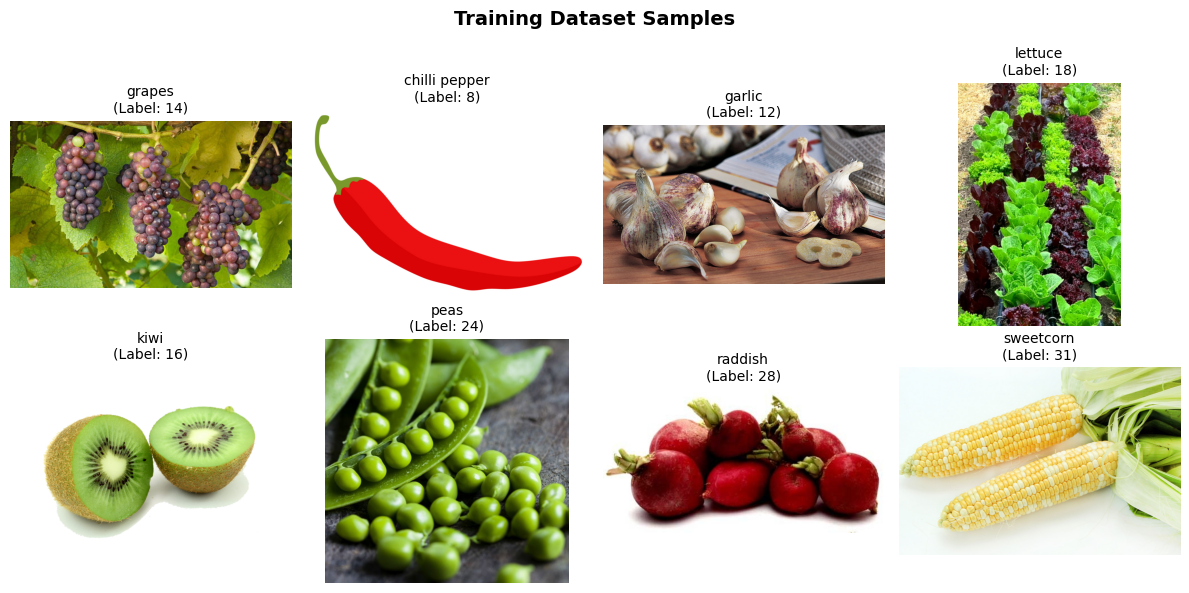

## Tire Texture Image Recognition

![image.png](https://storage.googleapis.com/kaggle-datasets-images/1731575/2830785/89236052a51930ac60fe7d2ccff1a48a/dataset-cover.jpeg?t=2021-11-19-19-33-01)

In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("jehanbhathena/tire-texture-image-recognition")        # Data Classified into train, test

print("Path to dataset files:", path)

100%|██████████| 708M/708M [00:10<00:00, 70.6MB/s]

Extracting files...


Path to dataset files: /content/data/datasets/jehanbhathena/tire-texture-image-recognition/versions/1


# TO-DO :)

## **Example 2: CSV-Labeled Dataset (Unsplit)**

**Dataset:** 20 Fonts Classification  
**Structure:** All images in one folder + CSV file with labels

**Challenges:**
- Labels are in a CSV file, not folder names
- Data is **not split** - we need to create train/val/test splits manually
- Need to parse CSV to map images to labels

This is more complex but very common in real-world datasets.

## 20 Fonts Classification

![image.png](https://storage.googleapis.com/kaggle-datasets-images/6516839/10530509/966d95523da75a3a94efae86f08d8a62/dataset-cover.jpg?t=2025-01-20-20-36-23)/


In [ ]:
import kagglehub

# Download latest version
fonts_path = kagglehub.dataset_download("samoilovmikhail/20-fonts-classification")            # Data given in one folder unsplitted + csv

print("Path to dataset files:", path)

Using Colab cache for faster access to the '20-fonts-classification' dataset.
Path to dataset files: /kaggle/input/20-fonts-classification


### **Step 1: Inspect the Dataset Structure**

With CSV-based datasets, we need to:
1. Find the CSV file location
2. Understand the CSV format (columns, headers)
3. Locate the images folder
4. Check if images match the CSV entries

Top-level contents:
📁 files/ - 20000 files
📄 metadata.csv


CSV files found: ['metadata.csv']

CSV shape: (20000, 3)
Columns: ['FileName', 'Font', 'Text']

First 10 rows:
      FileName           Font      Text
0   file_1.png     CourierNew  Sediment
1   file_2.png          Arial     Guest
2   file_3.png  CenturyGothic    Socket
3   file_4.png        Verdana     Onset
4   file_5.png        Candara    Driver
5   file_6.png  TimesNewRoman   Oakland
6   file_7.png       Garamond     Breed
7   file_8.png  TimesNewRoman   Garrett
8   file_9.png       Palatino      Tens
9  file_10.png        Calibri      Arts

Unique labels: 20
Label distribution:
Font
CourierNew       1000
Arial            1000
CenturyGothic    1000
Verdana          1000
Candara          1000
TimesNewRoman    1000
Garamond         1000
Palatino         1000
Calibri          1000
Lobster          1000
Name: count, dtype: int64


**What we discovered:**
- ✅ CSV file contains `image` (filename) and `label` (class name) columns
- ✅ All images are in a single `data/` folder (not split by class)
- ✅ The dataset is **unsplit** - we'll need to create train/val/test splits
- ✅ Multiple fonts (classes) are represented

**Key Differences from Example 1:**
- Labels come from CSV, not folder structure
- Need to manually split the data
- All images mixed together in one folder

### **Step 2: Build a Custom Dataset Class for CSV-Based Data**

This Dataset class is different because:
1. **Reads labels from CSV** instead of folder names
2. **Supports train/val/test splitting** using indices
3. **No class folders** - all images in one location

We'll use `train_test_split` from scikit-learn to create splits.

**Key differences from the folder-based Dataset:**

1. **CSV Loading:**
   - Reads labels from CSV file instead of folder structure
   - Creates `class_to_idx` mapping from unique labels in CSV

2. **Data Splitting:**
   - Uses `train_test_split` with **stratification** (maintains class distribution)
   - Splits happen **inside** `__init__` based on the `split` parameter
   - Same CSV file used for all splits, but different rows are selected

3. **File Path Construction:**
   - Must specify `images_folder` since all images are together
   - Combines `root_dir + images_folder + filename` to get full path

4. **Why Stratified Split?**
   - Ensures each class appears proportionally in train/val/test
   - Prevents train set from having all samples of certain classes

Train samples: 13999
Validation samples: 3000
Test samples: 3001
Number of classes: 20
Classes (first 5): ['Arial', 'Bookman', 'Calibri', 'Candara', 'CenturyGothic']


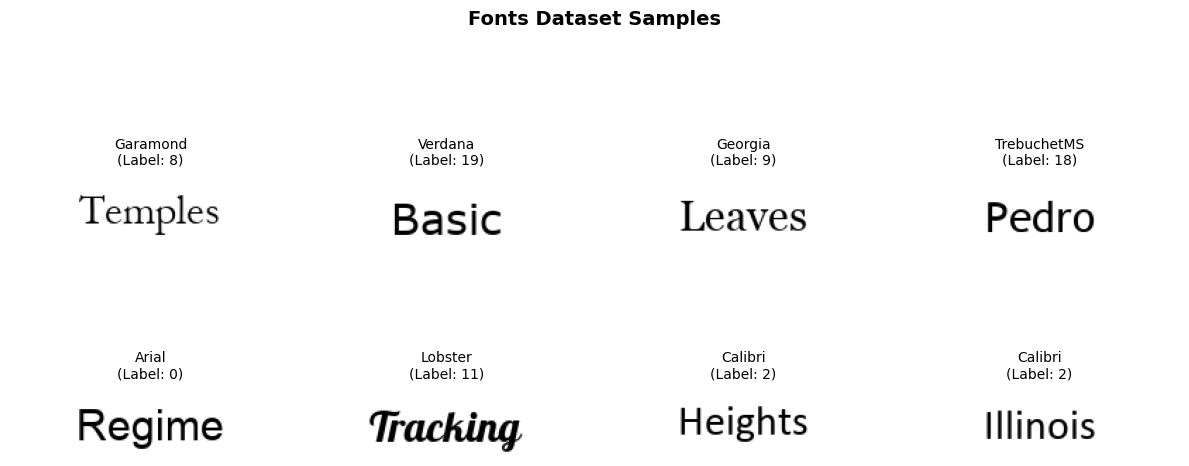


Sample details:
Image shape: torch.Size([3, 50, 200])
Label: 2
Class name: Calibri


---

In [ ]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from torchvision.datasets import ImageFolder
import kagglehub
import os
from PIL import Image
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

## Extra Practice Dataset: Bone Fracture Split Classification

![image.png](https://storage.googleapis.com/kaggle-datasets-images/5013401/8421103/1dc812e422a61e5d54d7f0760c0aeeb1/dataset-cover.png?t=2024-05-15-13-48-14)

##### This dataset contains **X-ray images** of various types of bone fractures, categorized into **12 classes**.




In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("shyamgupta196/bone-fracture-split-classification")

print("Path to dataset files:", path)

##### Note: You can build a custom dataset class or use any torch built-in dataset classes (e.g. TensorDataset, ImageFolder,...)

In [ ]:
class_to_idx = {
    "Avulsion fracture": 0,
    "Comminuted fracture": 1,
    "Compression-Crush fracture": 2,
    "Fracture Dislocation": 3,
    "Greenstick fracture": 4,
    "Hairline Fracture": 5,
    "Impacted fracture": 6,
    "Intra-articular fracture": 7,
    "Longitudinal fracture": 8,
    "Oblique fracture": 9,
    "Pathological fracture": 10,
    "Spiral Fracture": 11
}


### Display some images from the dataset

### Contributed by: Abdulellah Mojalled

![image.png](https://i.imgur.com/a3uAqnb.png)